# Lab Task 04 - Part 2

# The following code comes from the lab on Tuesday, June 9, UP UNTIL THE "LabTask: Complete feature family 2" cell. This Jupyter Notebook file does not include the in-between text from the corresponding scaffold.

In [84]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

log = pd.read_csv("transformed_dataset.csv")
grades = pd.read_csv('grades_data.csv')

print(grades.head(10))

   userID      A1      A2      A3     A4      A5  FinalScore
0  100001   93.75   68.75  100.00  76.47   82.05       59.97
1  100002  112.50  125.00  100.00  88.24   92.31       77.81
2  100003  100.00  125.00  121.43  94.12   93.59       89.88
3  100004  116.67  125.00   75.00  52.94   57.69       73.30
4  100005   95.83  106.25   82.14  35.29   33.33       56.57
5  100006   70.83    8.33   96.43  47.06   33.33       44.06
6  100007  106.92   83.33   92.86  91.18   80.77       60.84
7  100008   77.08  100.00   92.86  50.00   88.46       67.17
8  100009   70.83   91.67   98.21  82.35   21.79       66.79
9  100010  108.33  108.33  101.79  85.29  106.41       84.66


In [85]:
grouped = log.groupby(['userID', 'assignment']).size().unstack(fill_value=0)

grouped = grouped.reindex(sorted(grouped.columns), axis=1)

grouped.columns = [f"{col}totalCount" for col in grouped.columns]

assignment_counts = grouped.reset_index()

print(f"Shape: {assignment_counts.shape} -> {assignment_counts.shape[0]} students, "
     f"{assignment_counts.shape[1]-1 } count features + userID")
assignment_counts.head()

Shape: (54, 6) -> 54 students, 5 count features + userID


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount
0,100001,38,37,37,61,48
1,100002,46,49,39,42,64
2,100003,38,33,37,24,29
3,100004,41,19,38,28,40
4,100005,27,52,51,27,51


In [86]:
time_totals = (
    log.groupby(['userID', 'assignment'])['view_length']
       .sum()
       .unstack(fill_value=0)
)
time_totals = time_totals.reindex(sorted(time_totals.columns), axis=1)
time_totals.columns = [f"{col}totalTime" for col in time_totals.columns]# f"" notation allows us to have a variable inside a string.

time_totals = time_totals.reset_index()

print(f"time_totals: {time_totals.shape}")

assignments = pd.merge(assignment_counts, time_totals, on='userID', how='left')#userID is the common column between these two dataframes

# left: time_totals gets merged into assignment_counts

print(f"Final shape: {assignments.shape}")

print("Columns:", assignments.columns.tolist())

assignments.head()

time_totals: (54, 6)
Final shape: (54, 11)
Columns: ['userID', 'a1totalCount', 'a2totalCount', 'a3totalCount', 'a4totalCount', 'a5totalCount', 'a1totalTime', 'a2totalTime', 'a3totalTime', 'a4totalTime', 'a5totalTime']


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


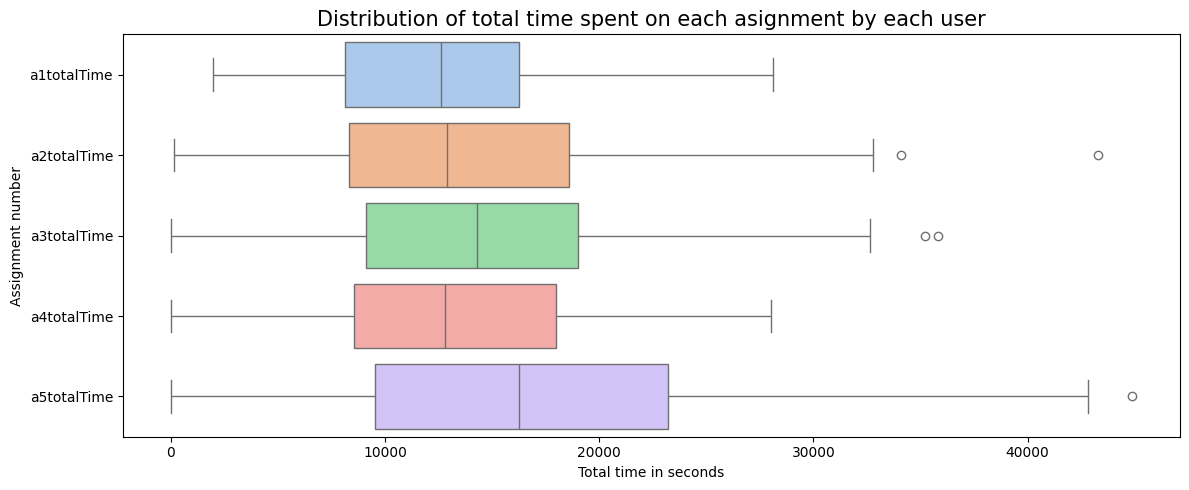

In [87]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=assignments.filter(like='totalTime'), orient='h', palette='pastel')#If has the string total Time, take it
plt.title("Distribution of total time spent on each asignment by each user", fontsize=15)
plt.xlabel('Total time in seconds')
plt.ylabel('Assignment number')
plt.tight_layout()
plt.show()

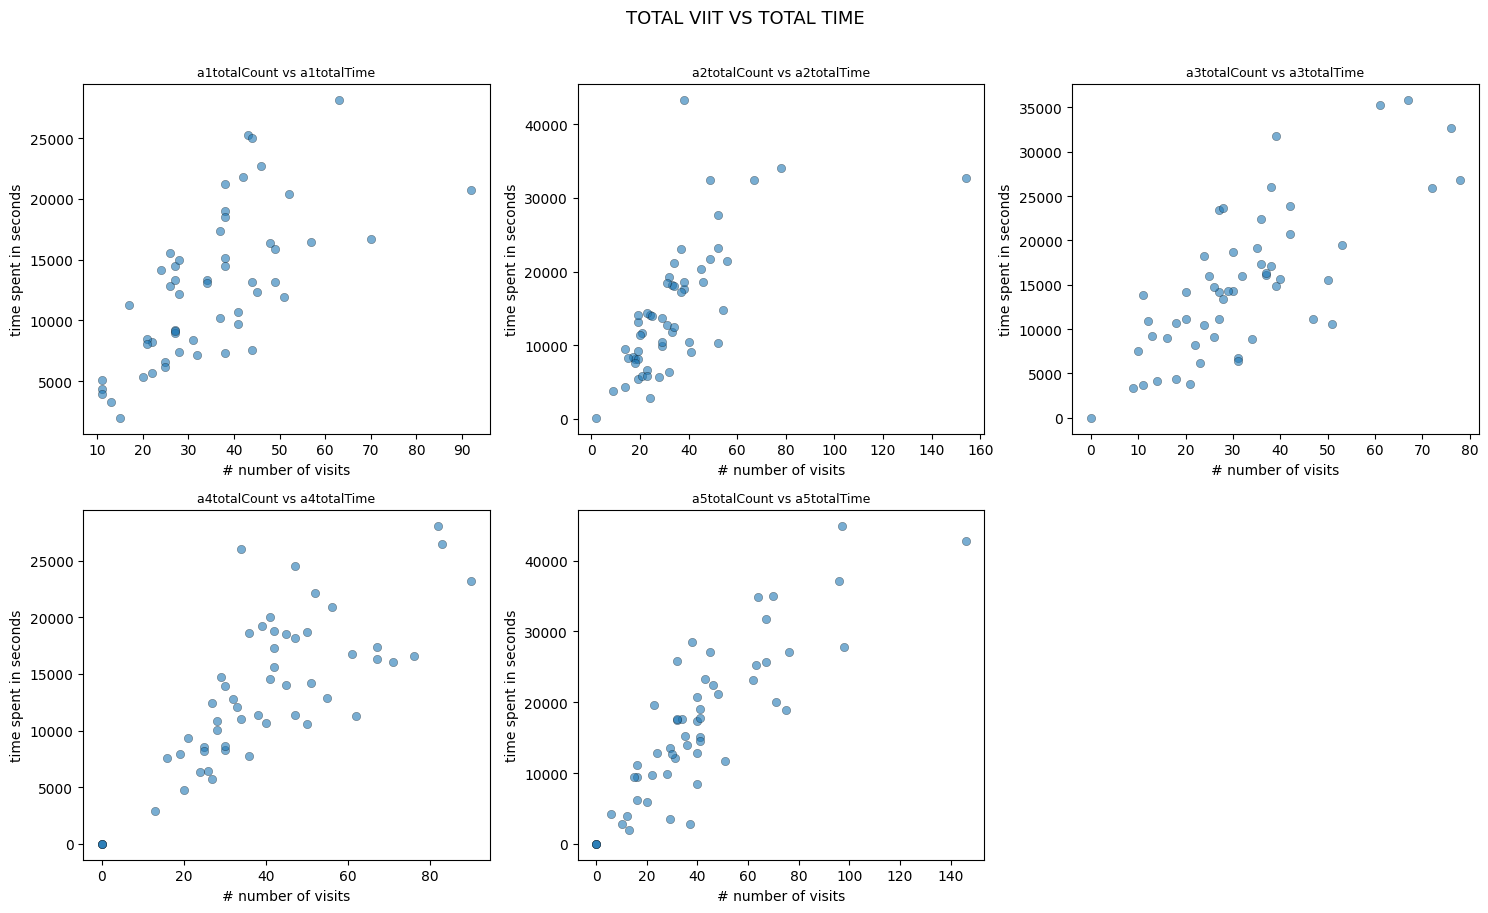

In [88]:

count_cols = assignments.filter(like='totalCount').columns.tolist()
n = len(count_cols)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(count_cols):
    time_col = col.replace('totalCount', 'totalTime')
    axes[i].scatter(assignments[col], assignments[time_col], alpha=0.6, edgecolors='k', linewidths=0.3)
    axes[i].set_title(f"{col} vs {time_col}", fontsize=9)
    axes[i].set_xlabel("# number of visits")
    axes[i].set_ylabel("time spent in seconds")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('TOTAL VIIT VS TOTAL TIME', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [89]:
grades = pd.merge(grades, assignments, on="userID", how='left')

print(f"Grades DataFrame shape: {grades.shape}" )
grades.head()

Grades DataFrame shape: (54, 17)


,userID,A1,A2,A3,A4,A5,FinalScore,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,93.75,68.75,100.00,76.47,82.05,59.97,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,112.50,125.00,100.00,88.24,92.31,77.81,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,100.00,125.00,121.43,94.12,93.59,89.88,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,116.67,125.00,75.00,52.94,57.69,73.30,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,95.83,106.25,82.14,35.29,33.33,56.57,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


In [90]:
correlation_results = {}

for i in range(1, 6):
    grade_col = f'A{i}'
    time_col = f'a{i} total time'

    if grade_col in grades.columns and time_col in grades.columns:
        corr = grades[[grade_col, time_col]].corr.iloc[0, 1]
        print(corr, "test")
        correlation_results[grade_col] = round(corr, 3) #for a specific assignment

print("let's see if there's a correlation between grades and total time spent on an assignment: ")

print(correlation_results)
for k, v in correlation_results.items():
    print(f" {k} ~ {k.lower()}totalTime: r = {v}")

let's see if there's a correlation between grades and total time spent on an assignment: 
{}


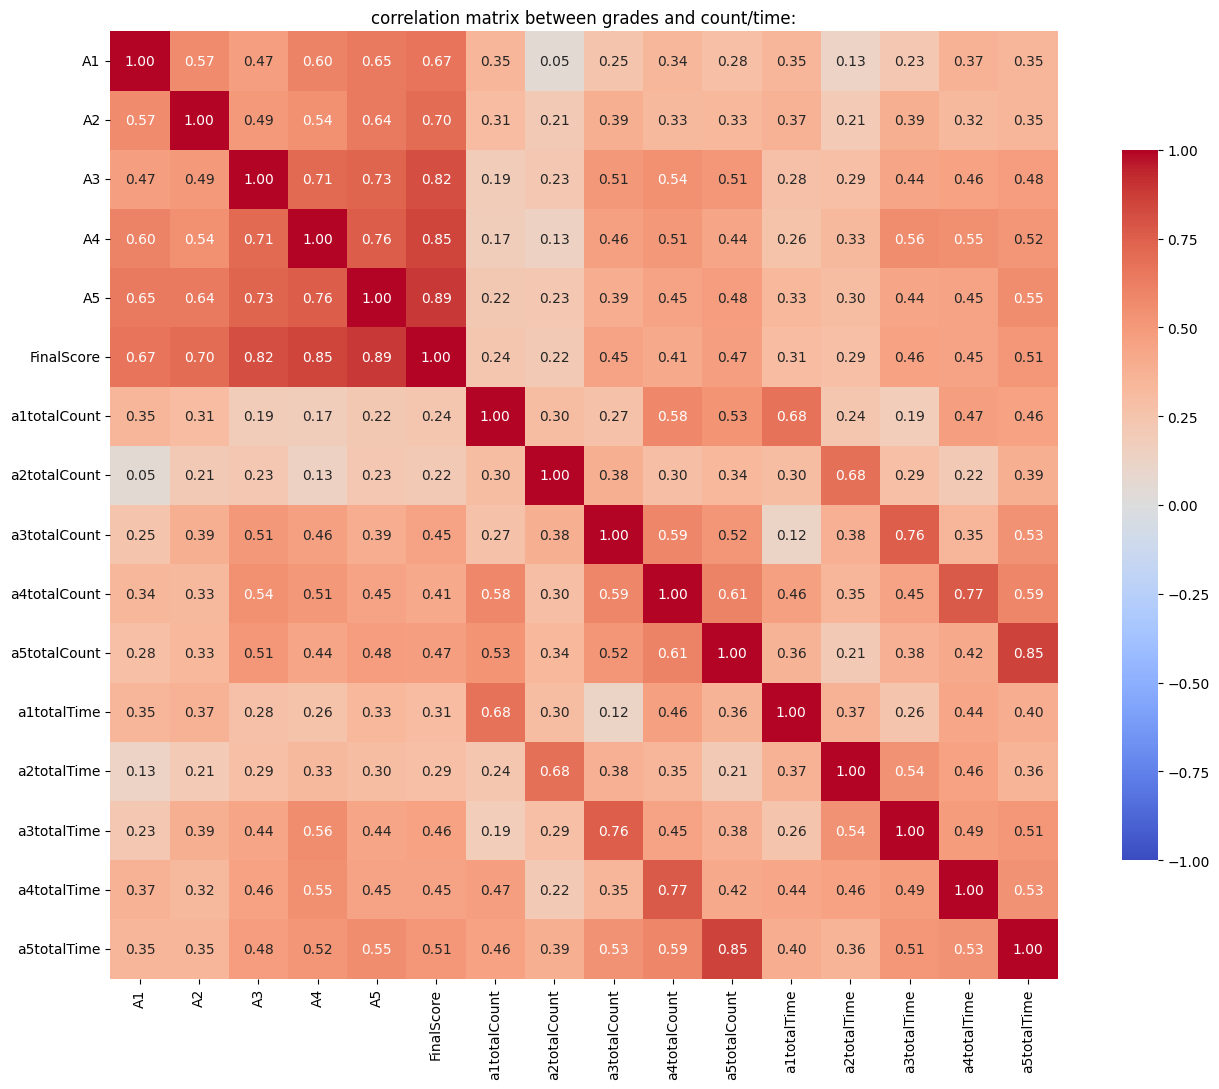

In [91]:
correlation_matrix = grades.drop(columns=['userID']).corr()

plt.figure(figsize=(14, 11))
sns.heatmap(
    correlation_matrix,
    annot=True, fmt=".2f", cmap='coolwarm',
    square=True, cbar_kws={"shrink": 0.75},
    vmin=-1, vmax=1
)

plt.title("correlation matrix between grades and count/time:")
plt.tight_layout()
plt.show()

In [92]:
a1deadline = pd.to_datetime('2026-05-27 23:59:00-07:00')
a2deadline = pd.to_datetime('2026-06-15 23:59:00-07:00')

deadlines = {
    'a1': a2deadline,
    'a2': a2deadline
}

print(deadlines)

for k, v in deadlines.items():
    print(f"{k}: {v.date()}") #Pandas object, so we can call attributes on it!

{'a1': Timestamp('2026-06-15 23:59:00-0700', tz='UTC-07:00'), 'a2': Timestamp('2026-06-15 23:59:00-0700', tz='UTC-07:00')}
a1: 2026-06-15
a2: 2026-06-15


In [95]:
log['start_time'] = pd.to_datetime(log['start_time'], utc=True) #If working iwth timezones, moify them!

log['date'] = log['start_time'].dt.date

# row is used to buil a temporal variable for each (student, assignment) pair 
rows= []

for (user, assignment), group in log.groupby(['userID', 'assignment']):
    if assignment not in deadlines:
        continue
    deadline = deadlines[assignment]

    dates = sorted(set(group['date']))

    days_before = [(deadline.date() - d).days for d in dates] #For each day in dates, calculate the day before based on what we've got, store it in a list.

    days_in_last_week = [d for d in dates if 0 <= (deadline.date() - d).days <= 7] # if the formula lies between 0 and 7, otherwise, ignore it and don't put in list

    rows.append({
        'userID': user,
        'assignment': assignment,
        'firstDay': days_before[0] if len(days_before) >= 1 else None,
        'secondDay': days_before[1] if len(days_before) >= 2 else None,

        'firstSecondGap': (days_before[0] - days_before[1]) if len(days_before) >= 2 else None,

        'nDays': len(dates),

        'nDaysFinalWeek': len(days_in_last_week),

        'nDaysBeforeFinalWeek': len([d for d in days_before if d > 7]),

        'nDaysAfterDeadline': len([d for d in days_before if d < 0]),
        }
               )

activity_summary = pd.DataFrame(rows)

print(f"activity dataframe Shape: {activity_summary.shape}")

activity_summary.head(10)


activity dataframe Shape: (108, 9)


,userID,assignment,firstDay,secondDay,firstSecondGap,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline
0,100001,a1,26,23,3,7,0,7,0
1,100001,a2,18,12,6,11,6,4,1
2,100002,a1,35,28,7,9,0,9,0
3,100002,a2,19,18,1,14,5,6,3
4,100003,a1,31,25,6,7,0,7,0
5,100003,a2,18,14,4,6,2,3,1
6,100004,a1,25,20,5,5,0,4,1
7,100004,a2,18,2,16,4,2,1,1
8,100005,a1,25,24,1,6,0,5,1
9,100005,a2,17,15,2,10,4,5,1


# LabTask: Complete feature family 2

# FROM HERE ON OUT, EVERYTHING IS ENTIRELY FROM THE SCAFFOLD.

### Reshaping the data: wide vs. long format

Right now `grades` is in **wide format** (one row per student, one column per assignment per feature).
`activity_summary` is in **long format** (one row per student–assignment pair).

To cleanly merge temporal features with grades, we'll convert everything to long format first.

> 💡 `pd.melt()` is the pandas function for converting from wide to long.
> It "unpivots" selected columns into rows.

In [113]:
long_grades = pd.melt(grades, id_vars=['userID'], value_vars=['a1totalTime', 'a2totalTime', 'a3totalTime', 'a4totalTime', 'a5totalTime'])
long_grades 

,userID,variable,value
0,100001,a1totalTime,18996.0
1,100002,a1totalTime,22696.0
2,100003,a1totalTime,21270.0
3,100004,a1totalTime,9699.0
4,100005,a1totalTime,9231.0
...,...,...,...
265,100050,a5totalTime,9925.0
266,100051,a5totalTime,0.0
267,100052,a5totalTime,27067.0
268,100053,a5totalTime,0.0


Now merge the temporal features into our long-format dataset.

In [116]:
merge_summary_grades = activity_summary.merge(long_grades, how='right') # We'll use userID as the consistent column between the two DataFrames

merge_summary_grades

,userID,assignment,firstDay,secondDay,firstSecondGap,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline,variable,value
0,100001,a1,26,23,3,7,0,7,0,a1totalTime,18996.0
1,100001,a2,18,12,6,11,6,4,1,a1totalTime,18996.0
2,100002,a1,35,28,7,9,0,9,0,a1totalTime,22696.0
3,100002,a2,19,18,1,14,5,6,3,a1totalTime,22696.0
4,100003,a1,31,25,6,7,0,7,0,a1totalTime,21270.0
...,...,...,...,...,...,...,...,...,...,...,...
535,100052,a2,5,2,3,4,3,0,1,a5totalTime,27067.0
536,100053,a1,20,19,1,3,0,3,0,a5totalTime,0.0
537,100053,a2,10,-1,11,2,0,1,1,a5totalTime,0.0
538,100054,a1,26,25,1,5,0,5,0,a5totalTime,2741.0


# Correlation matrix: all features vs. grades
Let's see how well our temporal features correlate with each assignment grade.

Because our data is now in long format, we first need to pivot it back to wide format so that each column corresponds to one (feature, assignment) combination — that's what we need for a heatmap.

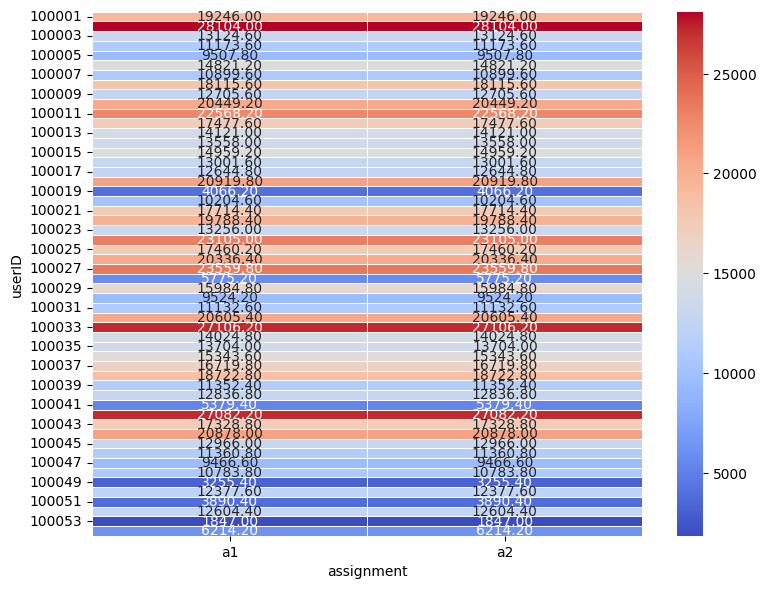

In [128]:
# back to wide format? I think I'd have to use pivot_table for this?

# Adapted from: https://www.geeksforgeeks.org/python/python-pandas-pivot_table

long_to_wide_summary = pd.pivot_table(
    merge_summary_grades, values='value', index="userID", columns="assignment")

long_to_wide_summary

plt.figure(figsize=(8,6 ))
sns.heatmap(long_to_wide_summary, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()

Some features are redundant (collinear): firstSecondGap can always be derived from firstDay and secondDay. Keeping redundant features in a regression model can cause instability. Let's drop them.

In [130]:
# Adapted from: https://www.w3schools.com/python/pandas/ref_df_drop.asp

merge_summary_grades_dropped = merge_summary_grades.drop("firstSecondGap", axis='columns')

merge_summary_grades_dropped

,userID,assignment,firstDay,secondDay,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline,variable,value
0,100001,a1,26,23,7,0,7,0,a1totalTime,18996.0
1,100001,a2,18,12,11,6,4,1,a1totalTime,18996.0
2,100002,a1,35,28,9,0,9,0,a1totalTime,22696.0
3,100002,a2,19,18,14,5,6,3,a1totalTime,22696.0
4,100003,a1,31,25,7,0,7,0,a1totalTime,21270.0
...,...,...,...,...,...,...,...,...,...,...
535,100052,a2,5,2,4,3,0,1,a5totalTime,27067.0
536,100053,a1,20,19,3,0,3,0,a5totalTime,0.0
537,100053,a2,10,-1,2,0,1,1,a5totalTime,0.0
538,100054,a1,26,25,5,0,5,0,a5totalTime,2741.0
